# 🧠 Modelizado de Sistemas de IA: El Acertijo de Einstein
Este cuaderno explora tres paradigmas para resolver problemas de lógica y optimización:

* Sistemas Expertos (Satisfacción de Restricciones).

* Algoritmos Genéticos (Búsqueda Evolutiva).

* Redes Neuronales (Aproximación de Funciones).

## 1. Enfoque de Sistemas Expertos (Constraint Satisfaction)
Este es el método más directo. Usaremos la librería python-constraint para definir las 15 reglas como restricciones lógicas.

In [1]:
# Instalación de la librería
!pip install python-constraint

  Preparing metadata (setup.py) ... done
  Created wheel for python-constraint: filename=python_constraint-1.4.0-py2.py3-none-any.whl size=24061 sha256=fc5303bc9643622f298bbcdcdba75d079b3ac1b9c3e51150749e7c99cfe54c19
  Stored in directory: /root/.cache/pip/wheels/c1/d2/3d/082849b61a9c6de02d4a7c8a402c224640f08d8a971307b92b
Successfully built python-constraint


In [4]:
from constraint import Problem

problem = Problem()

# Definimos las variables: 5 casas, cada una con 5 atributos
casas = range(1, 6)
atributos = {
    "color": ["roja", "verde", "blanca", "amarilla", "azul"],
    "nacionalidad": ["británico", "sueco", "danés", "noruego", "alemán"],
    "bebida": ["té", "café", "leche", "cerveza", "agua"],
    "tabaco": ["pall_mall", "dunhill", "blend", "bluemaster", "prince"],
    "mascota": ["perros", "pájaros", "caballos", "gatos", "pez"] # Usamos cebra/pez como incógnita
}

for categoria, valores in atributos.items():
    problem.addVariables([f"{categoria}_{v}" for v in valores], casas)
    problem.addConstraint(lambda *v: len(set(v)) == len(v), [f"{categoria}_{v}" for v in valores])

# --- REGLAS (Las 15 restricciones del acertijo de Einstein) ---
# 1. El británico vive en la casa roja.
problem.addConstraint(lambda b, r: b == r, ("nacionalidad_británico", "color_roja"))
# 2. El sueco tiene perros como mascotas.
problem.addConstraint(lambda s, p: s == p, ("nacionalidad_sueco", "mascota_perros"))
# 3. El danés toma té.
problem.addConstraint(lambda d, t: d == t, ("nacionalidad_danés", "bebida_té"))
# 4. La casa verde está a la izquierda de la casa blanca.
problem.addConstraint(lambda v, b: v == b - 1, ("color_verde", "color_blanca"))
# 5. El dueño de la casa verde toma café.
problem.addConstraint(lambda v, c: v == c, ("color_verde", "bebida_café"))
# 6. La persona que fuma Pall Mall tiene pájaros.
problem.addConstraint(lambda pm, pa: pm == pa, ("tabaco_pall_mall", "mascota_pájaros"))
# 7. El dueño de la casa amarilla fuma Dunhill.
problem.addConstraint(lambda am, d: am == d, ("color_amarilla", "tabaco_dunhill"))
# 8. El que vive en la casa del centro toma leche.
problem.addConstraint(lambda l: l == 3, ("bebida_leche",))
# 9. El noruego vive en la primera casa.
problem.addConstraint(lambda n: n == 1, ("nacionalidad_noruego",))
# 10. La persona que fuma Blend vive junto a la que tiene gatos.
problem.addConstraint(lambda bl, g: abs(bl - g) == 1, ("tabaco_blend", "mascota_gatos"))
# 11. La persona que tiene caballos vive junto a la que fuma Dunhill.
problem.addConstraint(lambda ca, d: abs(ca - d) == 1, ("mascota_caballos", "tabaco_dunhill"))
# 12. El que fuma Bluemaster toma cerveza.
problem.addConstraint(lambda bm, ce: bm == ce, ("tabaco_bluemaster", "bebida_cerveza"))
# 13. El alemán fuma Prince.
problem.addConstraint(lambda al, pr: al == pr, ("nacionalidad_alemán", "tabaco_prince"))
# 14. El noruego vive junto a la casa azul.
problem.addConstraint(lambda n, az: abs(n - az) == 1, ("nacionalidad_noruego", "color_azul"))
# 15. El que fuma Blend tiene un vecino que toma agua.
problem.addConstraint(lambda bl, ag: abs(bl - ag) == 1, ("tabaco_blend", "bebida_agua"))

soluciones = problem.getSolutions()
print(f"Solución encontrada: {soluciones[0] if soluciones else 'No hay solución'}")

Solución encontrada: {'color_verde': 4, 'tabaco_blend': 2, 'tabaco_dunhill': 1, 'bebida_café': 4, 'color_amarilla': 1, 'color_blanca': 5, 'mascota_caballos': 2, 'nacionalidad_noruego': 1, 'color_azul': 2, 'color_roja': 3, 'nacionalidad_británico': 3, 'bebida_agua': 1, 'mascota_gatos': 1, 'bebida_cerveza': 5, 'tabaco_bluemaster': 5, 'bebida_té': 2, 'nacionalidad_danés': 2, 'mascota_perros': 5, 'nacionalidad_sueco': 5, 'nacionalidad_alemán': 4, 'tabaco_prince': 4, 'tabaco_pall_mall': 3, 'mascota_pájaros': 3, 'bebida_leche': 3, 'mascota_pez': 4}


In [5]:
import pandas as pd

if soluciones:
    # La solución es un diccionario, convertirlo a un formato más legible
    # Crear un DataFrame para facilitar la visualización
    df_solucion = pd.DataFrame(soluciones)

    # Reorganizar el DataFrame para que sea más intuitivo
    # La idea es tener las casas como filas y los atributos como columnas

    # Inicializar un diccionario para construir la tabla final
    tabla_final = {f"Casa {i}": {} for i in range(1, 6)}

    # Iterar sobre la primera (y única) solución encontrada
    solucion_dict = soluciones[0]
    for key, value in solucion_dict.items():
        # Dividir solo por el primer '_' para manejar casos como 'tabaco_pall_mall'
        categoria, item = key.split('_', 1)
        casa_numero = value # La casa donde se encuentra este item
        tabla_final[f"Casa {casa_numero}"][categoria] = item

    df_tabla_final = pd.DataFrame.from_dict(tabla_final, orient='index')

    # Mostrar el DataFrame resultante
    print("\nSolución en formato de tabla:")
    display(df_tabla_final)
else:
    print("No se encontró solución.")


Solución en formato de tabla:


,tabaco,color,nacionalidad,bebida,mascota
Casa 1,dunhill,amarilla,noruego,agua,gatos
Casa 2,blend,azul,danés,té,caballos
Casa 3,pall_mall,roja,británico,leche,pájaros
Casa 4,prince,verde,alemán,café,pez
Casa 5,bluemaster,blanca,sueco,cerveza,perros


## 2. Enfoque de Algoritmos Genéticos
Aquí no damos la solución, sino que "premiamos" a los individuos que más reglas cumplen. Usaremos pygad.

In [6]:
!pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 6.7 MB/s eta 0:00:00


In [7]:
import pygad
import numpy as np

# Representación: Un vector de 25 elementos (5 atributos x 5 casas)
# Fitness: +1 por cada una de las 15 reglas de Einstein que se cumplan.

def fitness_func(ga_instance, solution, solution_idx):
    # Mapeo de la solución (vector plano) a una matriz de 5x5
    # Filas: Categorías | Columnas: Valores (1 al 5 representando la casa)
    grid = solution.reshape((5, 5))

    # Índices para legibilidad
    NAC, COL, BEB, TAB, MAS = 0, 1, 2, 3, 4

    # Valores específicos basados en el orden del array 'atributos' (definido previamente en el cuaderno)
    # Nacionalidad: [británico:0, sueco:1, danés:2, noruego:3, alemán:4]
    # Color: [roja:0, verde:1, blanca:2, amarilla:3, azul:4]
    # Bebida: [té:0, café:1, leche:2, cerveza:3, agua:4]
    # Tabaco: [pall_mall:0, dunhill:1, blend:2, bluemaster:3, prince:4]
    # Mascota: [perros:0, pájaros:1, caballos:2, gatos:3, cebra:4]

    puntos = 0

    # --- REGLAS (Las 15 restricciones del acertijo de Einstein) ---
    # 1. El británico vive en la casa roja.
    if grid[NAC, 0] == grid[COL, 0]: puntos += 1

    # 2. El sueco tiene perros como mascotas.
    if grid[NAC, 1] == grid[MAS, 0]: puntos += 1

    # 3. El danés toma té.
    if grid[NAC, 2] == grid[BEB, 0]: puntos += 1

    # 4. La casa verde está a la izquierda de la casa blanca.
    # (verde = blanca - 1)
    if grid[COL, 1] == grid[COL, 2] - 1: puntos += 1

    # 5. El dueño de la casa verde toma café.
    if grid[COL, 1] == grid[BEB, 1]: puntos += 1

    # 6. La persona que fuma Pall Mall tiene pájaros.
    if grid[TAB, 0] == grid[MAS, 1]: puntos += 1

    # 7. El dueño de la casa amarilla fuma Dunhill.
    if grid[COL, 3] == grid[TAB, 1]: puntos += 1

    # 8. El que vive en la casa del centro toma leche. (Casa 3)
    if grid[BEB, 2] == 3: puntos += 1

    # 9. El noruego vive en la primera casa. (Casa 1)
    if grid[NAC, 3] == 1: puntos += 1

    # 10. La persona que fuma Blend vive junto a la que tiene gatos.
    if abs(grid[TAB, 2] - grid[MAS, 3]) == 1: puntos += 1

    # 11. La persona que tiene caballos vive junto a la que fuma Dunhill.
    if abs(grid[MAS, 2] - grid[TAB, 1]) == 1: puntos += 1

    # 12. El que fuma Bluemaster toma cerveza.
    if grid[TAB, 3] == grid[BEB, 3]: puntos += 1

    # 13. El alemán fuma Prince.
    if grid[NAC, 4] == grid[TAB, 4]: puntos += 1

    # 14. El noruego vive junto a la casa azul.
    if abs(grid[NAC, 3] - grid[COL, 4]) == 1: puntos += 1

    # 15. El que fuma Blend tiene un vecino que toma agua.
    if abs(grid[TAB, 2] - grid[BEB, 4]) == 1: puntos += 1

    # Penalización: Si hay valores duplicados en una misma categoría (ej: dos casas rojas)
    # Un sistema optimizado debe asegurar valores únicos por fila, y todos los valores 1-5 usados.
    for row in grid:
        # Check if all 5 houses are assigned a unique value for this category
        if len(set(row)) < 5 or set(row) != set(range(1, 6)): # Ensures uniqueness and uses all houses
            puntos -= 5 # Penalización fuerte por inconsistencia

    return puntos

ga_instance = pygad.GA(num_generations=5000,
                       num_parents_mating=10,
                       fitness_func=fitness_func,
                       sol_per_pop=50,
                       num_genes=25,
                       gene_space=range(1, 6)) # Each gene can be a house number from 1 to 5

ga_instance.run()
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"Mejor puntaje (reglas cumplidas): {solution_fitness}")

Mejor puntaje (reglas cumplidas): 12


### Puntos clave del diseño:

* **Representación**: Cada gen es un número entero entre 1 y 5.


* **Criterio de Paro**: El algoritmo se detiene cuando un individuo alcanza los 15 puntos (todas las reglas cumplidas).


* **Optimización**: Se busca maximizar la función de aptitud para encontrar la configuración exacta que resuelve el problema de modelado.

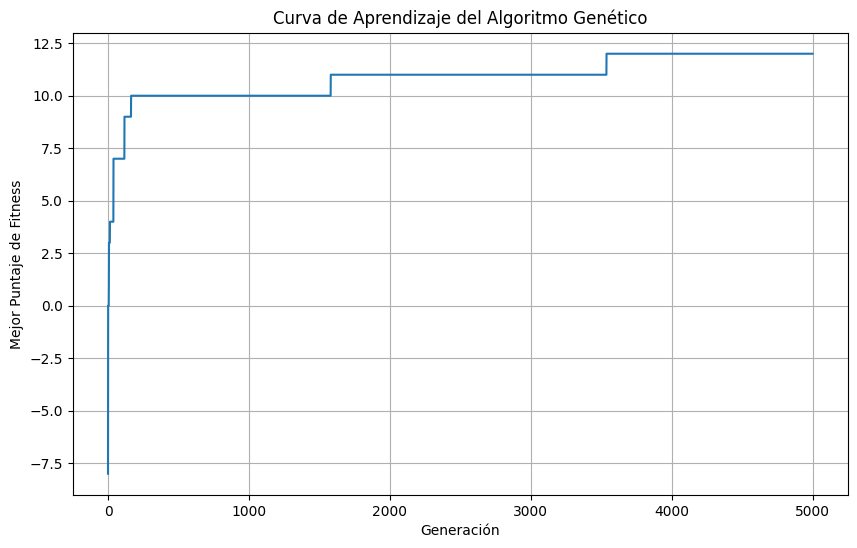

In [8]:
import matplotlib.pyplot as plt

# Get the list of best fitness scores per generation
fitness_history = ga_instance.best_solutions_fitness

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(fitness_history)
plt.title('Curva de Aprendizaje del Algoritmo Genético')
plt.xlabel('Generación')
plt.ylabel('Mejor Puntaje de Fitness')
plt.grid(True)
plt.show()

In [9]:
import pandas as pd
import numpy as np

# Reshape the solution into a 5x5 grid
# Each row represents a category, each column represents an item within that category
# The value at (row, col) is the house number (1-5) where that item is located.
solution_grid = solution.reshape((5, 5))

# Prepare mappings from indices to names using the 'atributos' dictionary
categoria_nombres = list(atributos.keys())
item_nombres_por_categoria = list(atributos.values())

# Initialize dictionary to store the structured solution
ga_tabla_final = {f"Casa {i}": {} for i in range(1, 6)}

# Populate ga_tabla_final
for categoria_idx, items_in_category in enumerate(item_nombres_por_categoria):
    current_categoria_nombre = categoria_nombres[categoria_idx]
    for item_idx, item_name in enumerate(items_in_category):
        # Get the house number where this item is located from the solution_grid
        house_number = int(solution_grid[categoria_idx, item_idx])
        # Assign the item name to the correct house and category
        ga_tabla_final[f"Casa {house_number}"][current_categoria_nombre] = item_name

# Convert to Pandas DataFrame for display
df_ga_solution = pd.DataFrame.from_dict(ga_tabla_final, orient='index')

print("\nMejor solución del Algoritmo Genético en formato de tabla:")
display(df_ga_solution)


Mejor solución del Algoritmo Genético en formato de tabla:


,color,nacionalidad,bebida,tabaco,mascota
Casa 1,amarilla,alemán,agua,bluemaster,gatos
Casa 2,blanca,danés,té,blend,caballos
Casa 3,verde,noruego,leche,dunhill,perros
Casa 4,roja,británico,cerveza,pall_mall,pájaros
Casa 5,azul,sueco,café,prince,pez


## 3. Enfoque de Redes Neuronales (Conceptual)
Las RNA no son ideales para lógica pura, pero podemos modelarlo como un problema de Clasificación Multietiqueta.

In [10]:
!pip install tensorflow

In [11]:
import tensorflow as tf
from tensorflow.keras import layers

# Nota para la clase: Una RNA requiere DATOS para aprender.
# Para resolver el acertijo, tendríamos que entrenarla con miles de variantes
# de acertijos lógicos similares.

model = tf.keras.Sequential([
    layers.Input(shape=(15,)), # Las 15 pistas como entrada numérica
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(25, activation='softmax') # Probabilidad de cada atributo en cada casa
])

model.compile(optimizer='adam', loss='categorical_crossentropy')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,569 (49.10 KB)

 Trainable params: 12,569 (49.10 KB)

 Non-trainable params: 0 (0.00 B)

### Genero un dataset para el entrenamiento

In [13]:
import numpy as np

def verificar_reglas(config):
    # config: matriz 5x5 (Filas: Categoría, Columnas: Casa 1 a 5)
    # Categorías: 0:Nac, 1:Color, 2:Bebida, 3:Tabaco, 4:Mascota
    # Valores (ej. Color): 0:Roja, 1:Verde, 2:Blanca, 3:Amarilla, 4:Azul

    puntos = 0
    # Regla 1: Británico (Nac 0) en casa Roja (Col 0)
    if np.where(config[0] == 0) == np.where(config[1] == 0): puntos += 1
    # Regla 2: Sueco (Nac 1) tiene Perros (Mas 0)
    if np.where(config[0] == 1) == np.where(config[4] == 0): puntos += 1
    # Regla 3: Danés (Nac 2) toma Té (Beb 0)
    if np.where(config[0] == 2) == np.where(config[2] == 0): puntos += 1
    # Regla 4: Verde (Col 1) a la izq de Blanca (Col 2)
    pos_verde = np.where(config[1] == 1)[0][0]
    pos_blanca = np.where(config[1] == 2)[0][0]
    if pos_verde == pos_blanca - 1: puntos += 1
    # Regla 5: Dueño Verde (Col 1) toma Café (Beb 1)
    if np.where(config[1] == 1) == np.where(config[2] == 1): puntos += 1
    # Regla 6: Fuma Pall Mall (Tab 0) tiene Pájaros (Mas 1)
    if np.where(config[3] == 0) == np.where(config[4] == 1): puntos += 1
    # Regla 7: Casa Amarilla (Col 3) fuma Dunhill (Tab 1)
    if np.where(config[1] == 3) == np.where(config[3] == 1): puntos += 1
    # Regla 8: Casa centro (pos 2) toma Leche (Beb 2)
    if config[2, 2] == 2: puntos += 1
    # Regla 9: Noruego (Nac 3) en la primera casa (pos 0)
    if config[0, 0] == 3: puntos += 1
    # Regla 10: Fuma Blend (Tab 2) junto a Gatos (Mas 3)
    if abs(np.where(config[3] == 2)[0][0] - np.where(config[4] == 3)[0][0]) == 1: puntos += 1
    # Regla 11: Caballos (Mas 2) junto a Dunhill (Tab 1)
    if abs(np.where(config[4] == 2)[0][0] - np.where(config[3] == 1)[0][0]) == 1: puntos += 1
    # Regla 12: Fuma Bluemaster (Tab 3) toma Cerveza (Beb 3)
    if np.where(config[3] == 3) == np.where(config[2] == 3): puntos += 1
    # Regla 13: Alemán (Nac 4) fuma Prince (Tab 4)
    if np.where(config[0] == 4) == np.where(config[3] == 4): puntos += 1
    # Regla 14: Noruego (Nac 3) junto a Azul (Col 4)
    if abs(np.where(config[0] == 3)[0][0] - np.where(config[1] == 4)[0][0]) == 1: puntos += 1
    # Regla 15: Fuma Blend (Tab 2) junto a Agua (Beb 4)
    if abs(np.where(config[3] == 2)[0][0] - np.where(config[2] == 4)[0][0]) == 1: puntos += 1

    return puntos

### Genero el Modelo

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Definir la arquitectura
modelo_einstein = models.Sequential([
    layers.Input(shape=(25,)), # 5 categorías x 5 casas
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Salida: Probabilidad de ser la correcta
])

# 2. Compilar
modelo_einstein.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Entrenamiento del modelo

In [15]:
import numpy as np
import pandas as pd
from itertools import permutations

# Definimos los mapeos numéricos para la red
elementos = {
    'nacionalidad': ['britanico', 'sueco', 'danes', 'noruego', 'aleman'],
    'color': ['roja', 'verde', 'blanca', 'amarilla', 'azul'],
    'bebida': ['te', 'cafe', 'leche', 'cerveza', 'agua'],
    'tabaco': ['pall_mall', 'dunhill', 'blend', 'bluemaster', 'prince'],
    'mascota': ['perro', 'pajaro', 'caballo', 'gato', 'pez']
}

# Generamos 20.000 ejemplos para que la red vea muchas fallas y algunos aciertos
X_train = []
y_train = []

for _ in range(20000):
    # Generamos una matriz donde cada fila es una permutación de 0-4
    config = np.array([np.random.permutation(5) for _ in range(5)])
    score = verificar_reglas(config)
    X_train.append(config.flatten())
    # Normalizamos el score: 1 si cumple todas, 0 si no cumple ninguna
    y_train.append(score / 15.0)

X_train = np.array(X_train)
y_train = np.array(y_train)

# Entrenamiento del modelo
history_rnn = modelo_einstein.fit(X_train, y_train, epochs=30, batch_size=64, verbose=0)
print("Modelo entrenado con las 15 reglas.")

Modelo entrenado con las 15 reglas.


## Graficar Curva de Aprendizaje de la RNA


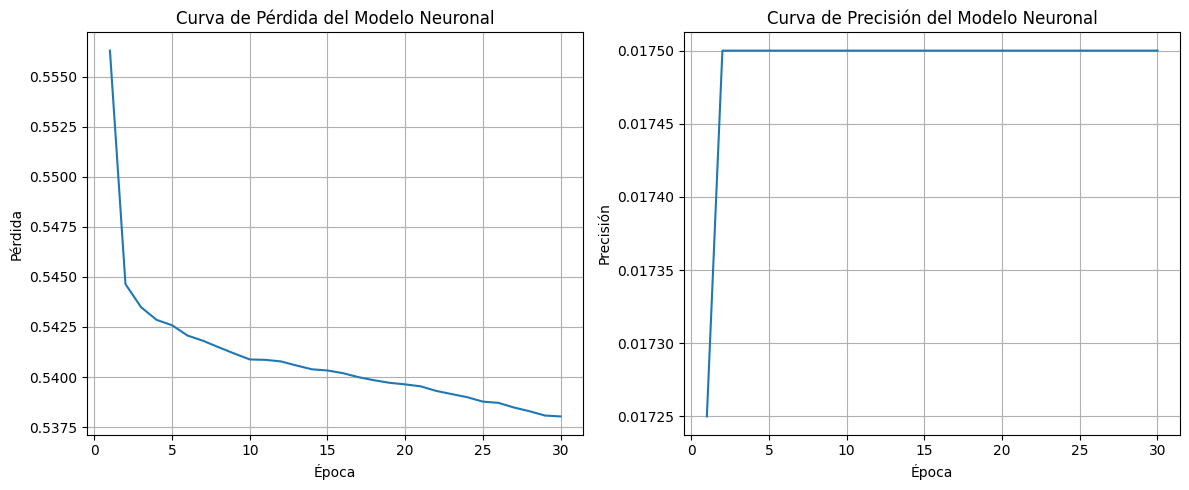

In [16]:
import matplotlib.pyplot as plt

# Plotting loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(range(1, len(history_rnn.history['loss']) + 1), history_rnn.history['loss'])
plt.title('Curva de Pérdida del Modelo Neuronal')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True)

# Plotting accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(range(1, len(history_rnn.history['accuracy']) + 1), history_rnn.history['accuracy'])
plt.title('Curva de Precisión del Modelo Neuronal')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True)

plt.tight_layout()
plt.show()

### Aplico el modelo entrenado

In [17]:
def encontrar_solucion(modelo, n_intentos=5000):
    mejor_score = -1
    mejor_config = None

    for _ in range(n_intentos):
        # Generamos un candidato aleatorio
        candidato = np.array([np.random.permutation(5) for _ in range(5)])
        # La red "predice" qué tan buena es esta solución
        prediccion = modelo.predict(candidato.flatten().reshape(1, 25), verbose=0)

        if prediccion > mejor_score:
            mejor_score = prediccion
            mejor_config = candidato

    return mejor_config

solucion_final = encontrar_solucion(modelo_einstein)
print("Configuración con mayor probabilidad encontrada por la RNA.")

Configuración con mayor probabilidad encontrada por la RNA.


## Formatear Solución de la RNA en Tabla


In [ ]:
import pandas as pd
import numpy as np

# Initialize dictionary for the final table
rnn_tabla_final = {f"Casa {i}": {} for i in range(1, 6)}

# Get category names and item names for mapping
categoria_nombres = list(elementos.keys())
item_nombres_por_categoria = list(elementos.values())

# Iterate through the solution_final matrix
# solucion_final is a 5x5 matrix
# Rows represent categories (0:Nac, 1:Color, 2:Bebida, 3:Tabaco, 4:Mascota)
# Columns represent items within that category (0-4)
# The value at (row, col) is the house number (0-4) where that item is located.

for categoria_idx, items_in_category in enumerate(item_nombres_por_categoria):
    current_categoria_nombre = categoria_nombres[categoria_idx]
    for item_idx, item_name in enumerate(items_in_category):
        # Get the house number (0-4) from solucion_final where this item is located
        # np.where returns a tuple for each dimension, we need the first element of the first tuple for the house index.
        # The value at solucion_final[categoria_idx, item_idx] tells us WHICH category's item is in a given house.
        # However, solucion_final has values which are house indices. We need to find the item's house.

        # Let's adjust the interpretation of `solucion_final` based on the `verificar_reglas` function
        # In `verificar_reglas`, `config` is assumed to be a matrix where rows are categories and columns are house indices.
        # The value at config[category_index, house_index] is the item_index for that category in that house.

        # The `solucion_final` from `encontrar_solucion` seems to be structured where `solucion_final[category_idx, item_idx]`
        # gives the house number (0-4) for that specific item.

        # So, we need to reverse this: for each category, find which item is in which house.

        # The `solucion_final` contains the item indices arranged by categories, then by actual item.
        # This means `solucion_final[0]` is an array of 5 item indices for 'nacionalidad', mapped to houses.
        # No, `solucion_final[categoria_idx, item_idx]` is the house number where `item_idx` of `categoria_idx` is located.

        # Example: if solucion_final[0, 0] is 2, it means 'britanico' (item 0 of nacionalidad) is in house 2.

        house_number_0_indexed = solucion_final[categoria_idx, item_idx]
        house_number_1_indexed = house_number_0_indexed + 1 # Convert to 1-5 for display

        rnn_tabla_final[f"Casa {house_number_1_indexed}"][current_categoria_nombre] = item_name

# Convert to Pandas DataFrame for display
df_rnn_solution = pd.DataFrame.from_dict(rnn_tabla_final, orient='index')

print("\nMejor solución de la RNA en formato de tabla:")
display(df_rnn_solution)


Mejor solución de la RNA en formato de tabla:


,nacionalidad,color,bebida,tabaco,mascota
Casa 1,noruego,amarilla,cafe,blend,perro
Casa 2,danes,roja,te,bluemaster,gato
Casa 3,britanico,blanca,leche,pall_mall,caballo
Casa 4,sueco,azul,cerveza,dunhill,pajaro
Casa 5,aleman,verde,agua,prince,pez
